In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from helpers.utils import set_seed, load_checkpoint
from eytnet.config import Config
from eytnet.model import build_model
from helpers.datahelper import FireDataset, collate_fn
from eytnet.dataset import build_dataloader
from eytnet.metrics import load_ground_truth, evaluate_detections, results_table
from eytnet.postprocess import collect_predictions
from eytnet.metrics_compat import evaluate_map, evaluate_full

In [5]:
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
DATA_DIR = PROJECT_ROOT / "data"
FRCNN_CKPT = PROJECT_ROOT / "models" / "runs" / "fasterrcnn_v2_unfreeze_l3_step16_22_es_full" / "weights" / "best.pt"
EYTNET_CONFIG = PROJECT_ROOT / "models" / "runs" / "eytnet_final_v1_opt_obj01" / "config.json"

In [7]:
NUM_CLASSES = 3  # background, fire, smoke
def build_fasterrcnn(trainable_backbone_layers=3):
    model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1, trainable_backbone_layers=trainable_backbone_layers)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
    model.transform.min_size = (640,)
    model.transform.max_size = 640
    return model

frcnn = build_fasterrcnn().to(device)
ckpt = load_checkpoint(FRCNN_CKPT, frcnn)
frcnn.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(640,), max_size=640, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, t

In [8]:
test_loader = DataLoader(
    FireDataset(DATA_DIR / "test", augment=False),
    batch_size=8,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

In [9]:
map50, aps50 = evaluate_map(frcnn, test_loader, device, iou_thresh=0.5)
map75, aps75 = evaluate_map(frcnn, test_loader, device, iou_thresh=0.75)

AP@0.50 fire: 0.946
AP@0.50 smoke: 0.916
mAP@0.50: 0.931
AP@0.75 fire: 0.708
AP@0.75 smoke: 0.592
mAP@0.75: 0.650


Test is a bit lower than the validation best (map50 0.951 → 0.931, map75 0.735 → 0.650). test split was never used for training or model selection. The larger drop is at IoU 0.75 especially on smoke

In [10]:
frcnn_full = evaluate_full(frcnn, test_loader, device)
results_table(frcnn_full)

,ap50,ap5095,precision,recall,f1,f2,tp,fp,fn
sinif,,,,,,,,,
fire,0.9458,0.6211,0.8776,0.9431,0.9092,0.9293,846,118,51
smoke,0.9156,0.5568,0.7856,0.9202,0.8476,0.8897,634,173,55
TOPLAM,0.9307,0.5889,0.8357,0.9332,0.8817,0.9119,1480,291,106


Faster R-CNN test (score threshold 0.25): mAP@0.5 0.931, mAP@0.5:0.95 0.589, P 0.836, R 0.933, F1 0.882. Smoke has more false positives than fire.

In [11]:
eytnet_cfg = Config.load(EYTNET_CONFIG)
eytnet_cfg.run_dir = PROJECT_ROOT / "models" / "runs" / "eytnet_final_v1_opt_obj01"
eytnet = build_model(eytnet_cfg).to(device)
eytnet_ckpt = load_checkpoint(eytnet_cfg.run_dir / "weights" / "best.pt", eytnet)
eytnet.eval()

EYTNet(
  (stem): FireFeatureBlock(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1, inplace=True)
    )
  )
  (stage1): Sequential(
    (0): FireFeatureBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.1, inplace=True)
      )
    )
    (1): FireFeatureBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.1, inplace=True)
      )
    )
  )
  (stage2): Sequ

In [12]:
eytnet_test_loader = build_dataloader(eytnet_cfg, "test")
preds = collect_predictions(eytnet, eytnet_test_loader, eytnet_cfg, device)
gt = load_ground_truth(DATA_DIR, "test")
results = evaluate_detections(preds, gt, eytnet_cfg.class_names ,map5095=True)
results_table(results)

,ap50,ap5095,precision,recall,f1,f2,tp,fp,fn
sinif,,,,,,,,,
fire,0.5574,0.2769,0.2967,0.7414,0.4238,0.5704,665,1576,232
smoke,0.1733,0.0639,0.2263,0.2743,0.2480,0.2632,189,646,500
TOPLAM,0.3653,0.1704,0.2776,0.5385,0.3664,0.4533,854,2222,732


EYT-Net test (score threshold 0.25): mAP@0.5 0.365, mAP@0.5:0.95 0.170, P 0.278, R 0.539, F1 0.366. Much weaker than Faster R-CNN as expected for a from-scratch detector versus a pretrained model. Smoke is the main failure mode fire AP@0.5 is 0.557 but precision is low because of many false positives.

In [13]:
results75 = evaluate_detections(preds, gt, eytnet_cfg.class_names, iou_threshold=0.75)
results_table(results75)

,ap50,ap5095,precision,recall,f1,f2,tp,fp,fn
sinif,,,,,,,,,
fire,0.2324,NaN,0.1669,0.4169,0.2384,0.3208,374,1867,523
smoke,0.0303,NaN,0.0994,0.1205,0.1089,0.1156,83,752,606
TOPLAM,0.1314,NaN,0.1486,0.2881,0.1961,0.2426,457,2619,1129


EYT-Net mAP@0.75 is 0.131 (fire 0.232, smoke 0.030) versus 0.650 for Faster R-CNN. Localization is weak, especially on smoke. The ap50 column in this table is AP at IoU 0.75

In [14]:
from eytnet.postprocess import collect_predictions as collect_eytnet
from eytnet.metrics_compat import collect_predictions as collect_frcnn
from eytnet.metrics import confidence_sweep
import pandas as pd

In [15]:
frcnn_val_loader = DataLoader(
    FireDataset(DATA_DIR / "val", augment=False),
    batch_size=8, shuffle=False, num_workers=0, collate_fn=collate_fn,
)

frcnn_val_preds, frcnn_val_gt = collect_frcnn(frcnn, frcnn_val_loader, device)
frcnn_sweep = pd.DataFrame(confidence_sweep(frcnn_val_preds, frcnn_val_gt, ["fire", "smoke"]))

In [16]:
display(frcnn_sweep)

,threshold,precision,recall,f1,f2,tp,fp,fn
0,0.05,0.755929,0.968354,0.849057,0.916826,1530,494,50
1,0.10,0.805277,0.965823,0.878273,0.928789,1526,369,54
2,0.15,0.837094,0.962658,0.895496,0.934620,1521,296,59
3,0.20,0.855775,0.961392,0.905514,0.938233,1519,256,61
4,0.25,0.870838,0.960127,0.913305,0.940834,1517,225,63
5,0.30,0.878120,0.957595,0.916137,0.940569,1513,210,67
6,0.40,0.894675,0.956962,0.924771,0.943820,1512,178,68
7,0.50,0.909475,0.953797,0.931109,0.944591,1507,150,73
8,0.60,0.915648,0.948101,0.931592,0.941428,1498,138,82


In [17]:
eytnet_val_loader = build_dataloader(eytnet_cfg, "val")
eytnet_val_preds = collect_eytnet(eytnet, eytnet_val_loader, eytnet_cfg, device)
eytnet_val_gt = load_ground_truth(DATA_DIR, "val")
eytnet_sweep = pd.DataFrame(confidence_sweep(eytnet_val_preds, eytnet_val_gt, eytnet_cfg.class_names))

In [18]:
display(eytnet_sweep)

,threshold,precision,recall,f1,f2,tp,fp,fn
0,0.05,0.063273,0.841772,0.117699,0.243233,1330,19690,250
1,0.10,0.118854,0.777215,0.206179,0.368724,1228,9104,352
2,0.15,0.174432,0.739241,0.282262,0.448679,1168,5528,412
3,0.20,0.225899,0.695570,0.341040,0.491283,1099,3766,481
4,0.25,0.279829,0.662025,0.393381,0.519984,1046,2692,534
5,0.30,0.328151,0.627848,0.431023,0.530879,992,2031,588
6,0.40,0.434677,0.566456,0.491893,0.534073,895,1164,685
7,0.50,0.537074,0.508861,0.522587,0.514264,804,693,776
8,0.60,0.630755,0.433544,0.513878,0.462463,685,401,895


In [19]:
frcnn_thresh = float(frcnn_sweep.loc[frcnn_sweep["f2"].idxmax(), "threshold"])
eytnet_thresh = float(eytnet_sweep.loc[eytnet_sweep["f2"].idxmax(), "threshold"])
print("FRCNN threshold:", frcnn_thresh, "| EYT-Net threshold:", eytnet_thresh)

FRCNN threshold: 0.5 | EYT-Net threshold: 0.4


Confidence thresholds were chosen on the validation set by maximizing F2. Faster R-CNN selected 0.5, EYT-Net selected 0.4

In [20]:
frcnn_test = evaluate_full(frcnn, test_loader, device, score_thresh=frcnn_thresh)
display(results_table(frcnn_test))

,ap50,ap5095,precision,recall,f1,f2,tp,fp,fn
sinif,,,,,,,,,
fire,0.9458,0.6211,0.9037,0.9309,0.9171,0.9253,835,89,62
smoke,0.9156,0.5568,0.8426,0.9013,0.8710,0.8889,621,116,68
TOPLAM,0.9307,0.5889,0.8766,0.9180,0.8968,0.9094,1456,205,130


In [21]:
eytnet_test = evaluate_detections(preds, gt, eytnet_cfg.class_names, score_threshold=eytnet_thresh, map5095=True)
display(results_table(eytnet_test))

,ap50,ap5095,precision,recall,f1,f2,tp,fp,fn
sinif,,,,,,,,,
fire,0.5574,0.2769,0.4287,0.6533,0.5177,0.5913,586,781,311
smoke,0.1733,0.0639,0.3539,0.1916,0.2486,0.2109,132,241,557
TOPLAM,0.3653,0.1704,0.4126,0.4527,0.4317,0.4441,718,1022,868


Retest on the held-out test set with the validation-chosen thresholds. AP is unchanged because it does not depend on the operating threshold. Raising the threshold cuts false positives especially for EYT-Net.

Now lets investigate inference time

In [22]:
import time
from PIL import Image
from helpers.preprocess import preprocess
from eytnet.postprocess import predict_image

In [23]:
paths = sorted((DATA_DIR / "test" / "images").glob("*.jpg"))[:50]

frcnn.eval()
t0 = time.time()
for path in paths:
    img = Image.open(path).convert("RGB")
    tensor, _, _, _ = preprocess(img)
    with torch.no_grad():
        frcnn([torch.from_numpy(tensor).to(device)]) # preprocess() returns a numpy array, torch tensor moves it to GPU, faster rcnn does not accept batched tensor, it wants python list of images [tensor] because it is designed to handle images that are different sizes
frcnn_ms = (time.time() - t0) * 1000 / len(paths)

In [24]:
eytnet.eval()
t0 = time.time()
for path in paths:
    img = Image.open(path).convert("RGB")
    with torch.no_grad():
        predict_image(eytnet, img, eytnet_cfg, device, score_threshold=eytnet_thresh)
eytnet_ms = (time.time() - t0) * 1000 / len(paths)

In [25]:
print("Faster R-CNN", frcnn_ms, "ms", 1000 / frcnn_ms, "FPS")
print("EYT-Net", eytnet_ms, "ms", 1000 / eytnet_ms, "FPS")

Faster R-CNN 95.6974983215332 ms 10.449593955320635 FPS
EYT-Net 30.634617805480957 ms 32.64280972426841 FPS


Inference on 50 test images (letterbox + forward). Faster R-CNN 96 ms for image (approx 10 FPS), EYT-Net 38 ms for image (approx 26 FPS). EYT-NET is faster. Tested on RTX 4060

In [35]:
o1 = frcnn_test["overall"]
o2 = eytnet_test["overall"]

pd.DataFrame([
    {
        "model": "Faster R-CNN",
        "thresh": frcnn_thresh,
        "map50": o1["map50"],
        "map75": 0.650, # sonucu manuel girdim
        "map5095": o1["map5095"],
        "P": o1["precision"],
        "R": o1["recall"],
        "F1": o1["f1"],
        "ms": frcnn_ms,
        "FPS": 1000 / frcnn_ms,
        },
    {
        "model": "EYT-Net",
        "thresh": eytnet_thresh,
        "map50": o2["map50"],
        "map75": 0.131, # manuel girdim
        "map5095": o2["map5095"],
        "P": o2["precision"],
        "R": o2["recall"],
        "F1": o2["f1"],
        "ms": eytnet_ms,
        "FPS": 1000 / eytnet_ms,
    },
])

,model,thresh,map50,map75,map5095,P,R,F1,ms,FPS
0,Faster R-CNN,0.5,0.930690,0.650,0.588915,0.876580,0.918033,0.896828,95.697498,10.449594
1,EYT-Net,0.4,0.365338,0.131,0.170384,0.412644,0.452711,0.431750,30.634618,32.642810


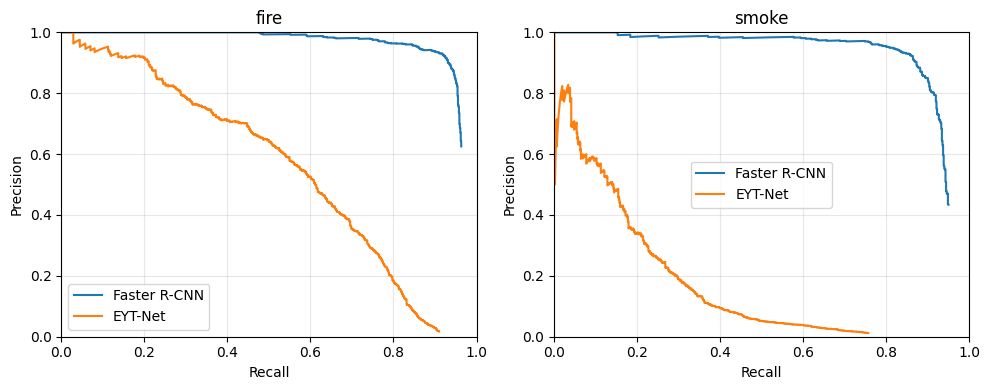

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ["fire", "smoke"]):
    rec_f, pre_f = frcnn_test["curves"][name]
    rec_e, pre_e = eytnet_test["curves"][name]
    ax.plot(rec_f, pre_f, label="Faster R-CNN")
    ax.plot(rec_e, pre_e, label="EYT-Net")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(name)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
from PIL import Image
from helpers.preprocess import preprocess
from helpers.viz import draw_bbox, draw_xyxy_boxes
from eytnet.metrics_compat import to_original
from eytnet.postprocess import predict_image

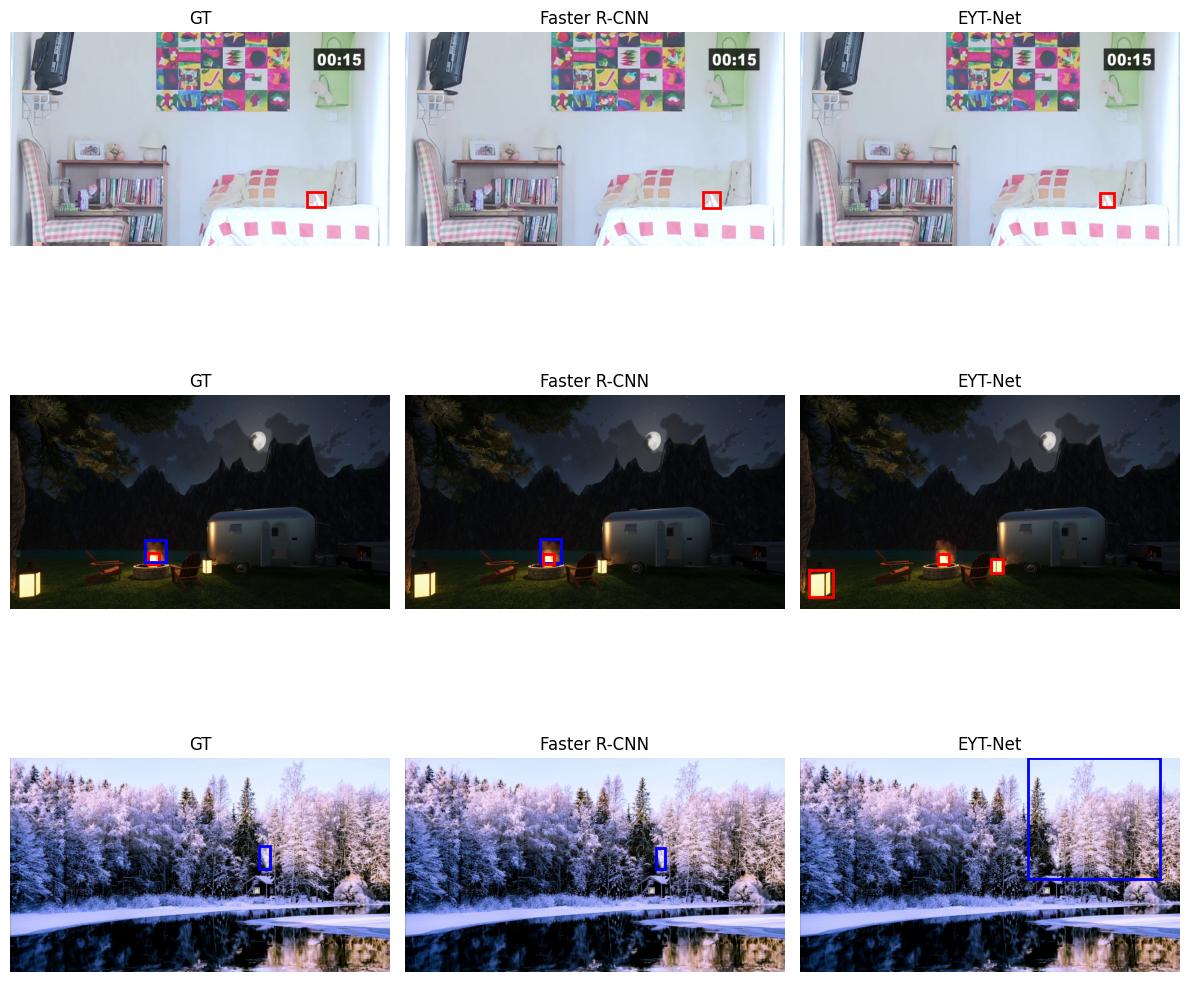

In [ ]:
paths = sorted((DATA_DIR / "test" / "images").glob("*.jpg"))
sample = [paths[25], paths[125], paths[75]]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i, path in enumerate(sample):
    img = Image.open(path).convert("RGB")
    label_path = DATA_DIR / "test" / "labels" / f"{path.stem}.txt"

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("GT")
    draw_bbox(axes[i, 0], label_path, path)
    axes[i, 0].axis("off")

    tensor, scale, pad_x, pad_y = preprocess(img)
    with torch.no_grad():
        out = frcnn([torch.from_numpy(tensor).to(device)])[0]

    meta = {
        "orig_width": img.size[0],
        "orig_height": img.size[1],
        "scale": scale,
        "pad_x": pad_x,
        "pad_y": pad_y,
    }    

    boxes = to_original(out["boxes"].cpu().numpy(), meta)
    axes[i, 1].imshow(img)
    axes[i, 1].set_title("Faster R-CNN")
    draw_xyxy_boxes(axes[i, 1], boxes, out["labels"].cpu(), out["scores"].cpu(), conf=frcnn_thresh)
    axes[i, 1].axis("off")

    det = predict_image(eytnet, img, eytnet_cfg, device, score_threshold=eytnet_thresh) # in predict_image, to_original is called internally so no need to call it here
    axes[i, 2].imshow(img)
    axes[i, 2].set_title("EYT-Net")
    if len(det):
        draw_xyxy_boxes(axes[i, 2], det[:, :4], det[:, 5] + 1, det[:, 4], conf=eytnet_thresh)
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import random
from PIL import Image
from helpers.preprocess import preprocess
from helpers.viz import draw_bbox, draw_xyxy_boxes
from eytnet.metrics_compat import to_original
from eytnet.postprocess import predict_image

In [42]:
DEMO_DIR = PROJECT_ROOT / "data" / "demo"
GOOD_DIR = DEMO_DIR / "good"
BAD_DIR = DEMO_DIR / "bad"

In [47]:
def run_demo(image_path):
    image_path = Path(image_path)
    img = Image.open(image_path).convert("RGB")
    label_path = DATA_DIR / "test" / "labels" / f"{image_path.stem}.txt"
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img)
    axes[0].set_title("GT")
    draw_bbox(axes[0], label_path, image_path)
    axes[0].axis("off")

    tensor, scale, pad_x, pad_y = preprocess(img)
    with torch.no_grad():
        out = frcnn([torch.from_numpy(tensor).to(device)])[0]
    meta = {
        "orig_width": img.size[0],
        "orig_height": img.size[1],
        "scale": scale,
        "pad_x": pad_x,
        "pad_y": pad_y,
    }

    boxes = to_original(out["boxes"].cpu().numpy(), meta)
    axes[1].imshow(img)
    axes[1].set_title("Faster R-CNN")
    draw_xyxy_boxes(axes[1], boxes, out["labels"].cpu(), out["scores"].cpu(), conf=frcnn_thresh)
    axes[1].axis("off")


    det = predict_image(eytnet, img, eytnet_cfg, device, score_threshold=eytnet_thresh)
    axes[2].imshow(img)
    axes[2].set_title("EYT-Net")
    if len(det):
        draw_xyxy_boxes(axes[2], det[:, :4], det[:, 5] + 1, det[:, 4], conf=eytnet_thresh)
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

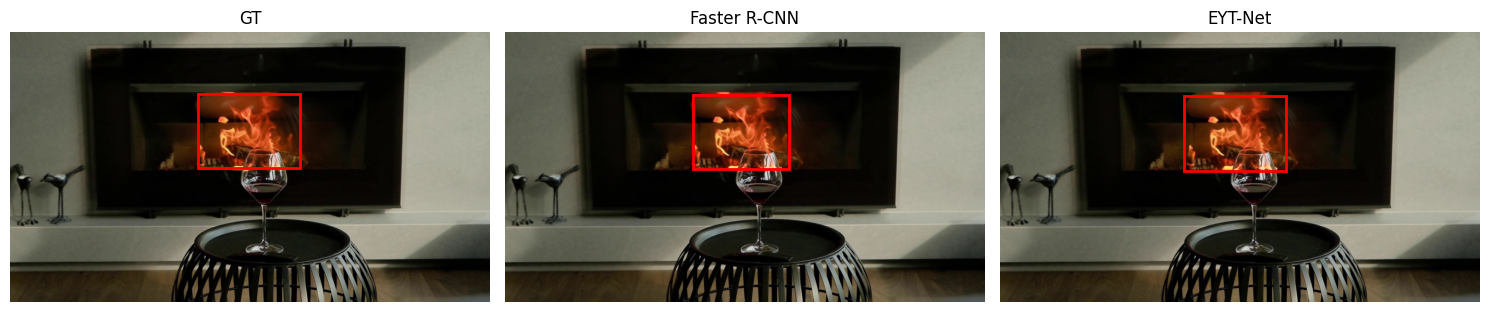

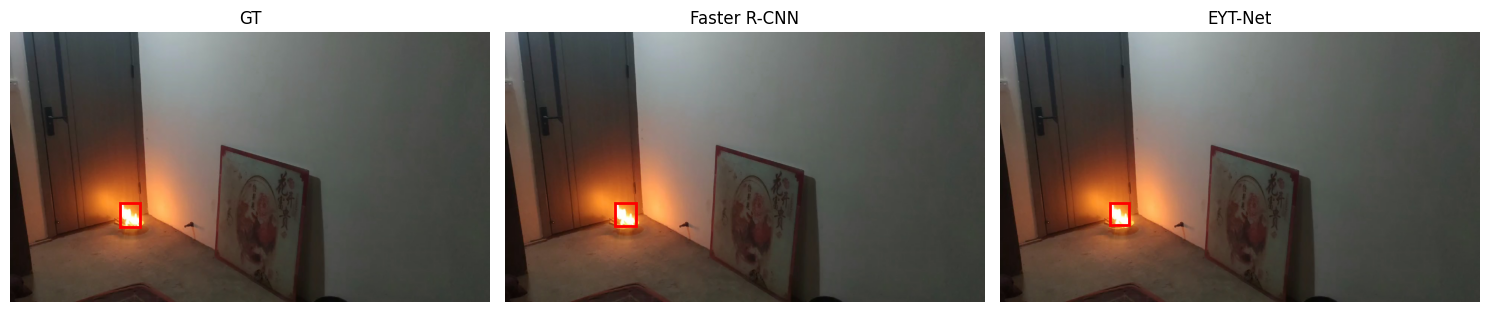

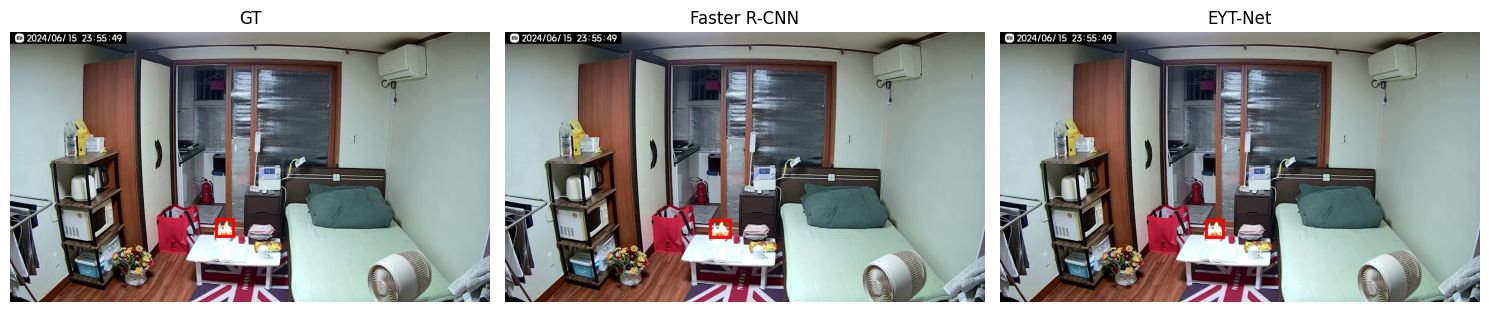

In [62]:
for i in range(3):
    run_demo(random.choice(list(GOOD_DIR.glob("*.jpg"))))

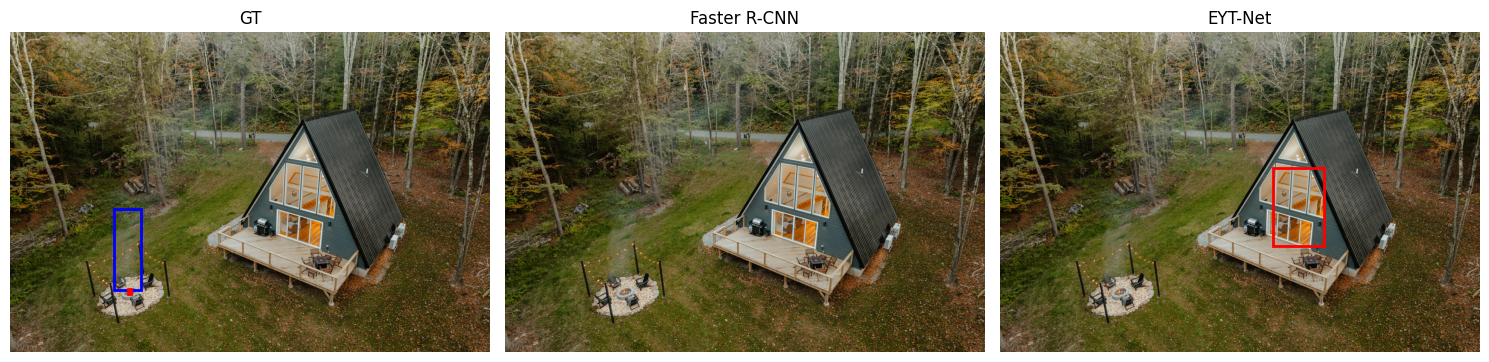

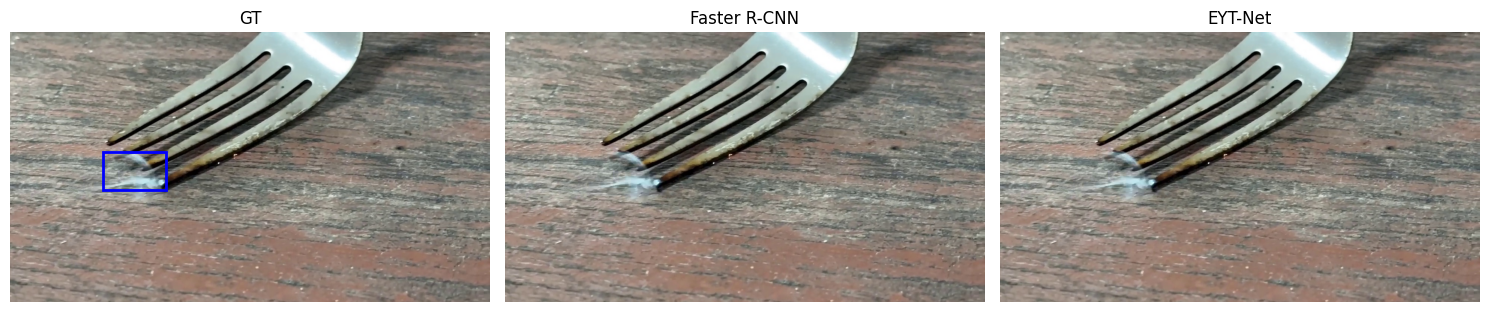

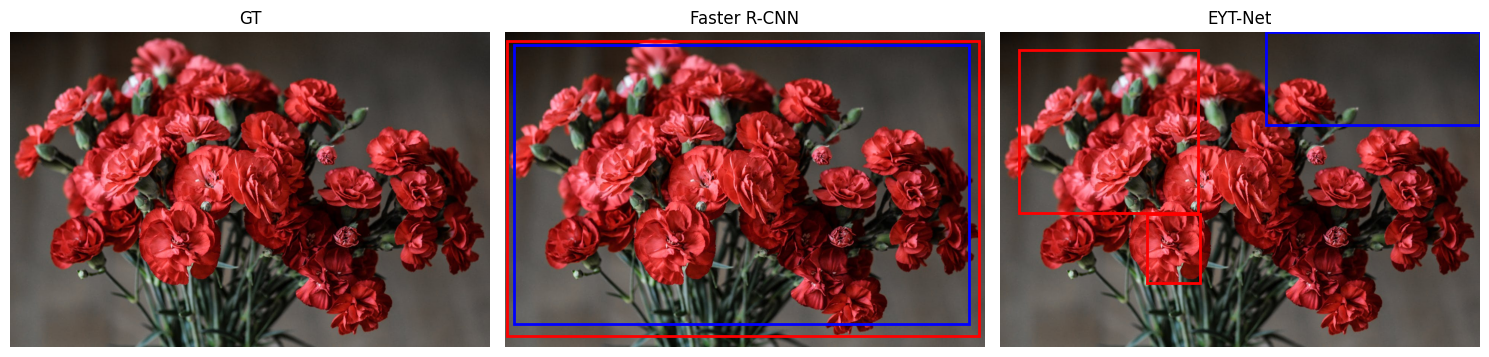

In [61]:
for i in range(3):
    run_demo(random.choice(list(BAD_DIR.glob("*.jpg"))))